# 01 — Data Preparation

This notebook covers:
- Downloading suggested public datasets
- Organising raw images/annotations
- Converting annotations to YOLO format
- Train / validation split
- Visualising sample annotations
- Data augmentation preview

In [1]:
# ── Install dependencies (run once) ──────────────────────────────────
# !pip install ultralytics opencv-python albumentations tqdm pyyaml gdown -q
import os, shutil, random, yaml, json, cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from pathlib import Path
from tqdm import tqdm

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
print("Libraries loaded ✓")

Libraries loaded ✓


## 1.1  Recommended Datasets

| Dataset | Contents | Source |
|---------|----------|--------|
| COCO 2017 | 80 classes incl. person, car, motorcycle, traffic light, cell phone | https://cocodataset.org |
| UA-DETRAC | Multi-vehicle traffic surveillance | https://detrac-db.rit.albany.edu |
| Indian Driving Dataset (IDD) | Indian road scenes | https://idd.insaan.iiit.ac.in |
| Helmet Detection Dataset | Helmets on motorcyclists | https://universe.roboflow.com/joseph-nelson/hardhat-sample |
| Traffic Signs (GTSDB) | Traffic signals & signs | https://benchmark.ini.rub.de |

We will use **COCO** as the base and supplement with Roboflow helmet + traffic-light datasets.

In [2]:
# ── Directory structure ───────────────────────────────────────────────
BASE = Path("../data")
RAW        = BASE / "raw"
PROCESSED  = BASE / "processed"
IMAGES_DIR = PROCESSED / "images"
LABELS_DIR = PROCESSED / "labels"

for d in [RAW, PROCESSED,
          IMAGES_DIR / "train", IMAGES_DIR / "val",
          LABELS_DIR / "train", LABELS_DIR / "val"]:
    d.mkdir(parents=True, exist_ok=True)

print("Directory structure created:")
for d in sorted(BASE.rglob("*")):
    print(" ", d)

Directory structure created:
  ..\data\processed
  ..\data\processed\data.yaml
  ..\data\processed\dataset.yaml
  ..\data\processed\images
  ..\data\processed\images\train
  ..\data\processed\images\val
  ..\data\processed\labels
  ..\data\processed\labels\train
  ..\data\processed\labels\val
  ..\data\processed\README.roboflow.txt
  ..\data\processed\train
  ..\data\processed\train\images
  ..\data\processed\train\images\-bike-without-helmet-breaking-traffic-rules-in-india-on-a-highway-1563212677_jpg.rf.9J04HCgzt7Uc0Ps65Th8.jpg
  ..\data\processed\train\images\-bike-without-helmet-breaking-traffic-rules-in-india-on-a-highway-1563212677_jpg.rf.w8ode3iduDGykHpMvSuv.jpg
  ..\data\processed\train\images\000000036469_jpg.rf.ulaJbltTXqlMKnYJ3qHC.jpg
  ..\data\processed\train\images\000000037826_jpg.rf.gUFdPHPjAtamkqTUe9h6.jpg
  ..\data\processed\train\images\000000105374_jpg.rf.3QIgo0IqSbo2BEZLHjM7.jpg
  ..\data\processed\train\images\000000108228_jpg.rf.2fkESFsJx5A7EhInYE0j.jpg
  ..\data\p

## 1.2  Download sample data via gdown / roboflow

> **Tip:** Replace the gdown IDs with the actual dataset IDs from Roboflow Export → YOLOv8 format.

In [7]:
# ─── Download a helmet-detection dataset from Roboflow (example) ──────
# Requires ROBOFLOW_API_KEY set in your environment
# Uncomment and run once:

from roboflow import Roboflow
rf = Roboflow(api_key="rjtQUaxF9OyOuK9XfXIl")
project = rf.workspace("pratham-masurkar-s-workspace").project("4classes-71hji-trvuu")
dataset = project.version(1).download("yolov8", location=str(RAW / "helmet"))

# ─── Or use gdown for a packaged dataset ──────────────────────────────
import gdown
gdown.download("https://drive.google.com/uc?id=<FILE_ID>",
               str(RAW / "traffic_data.zip"), quiet=False)
shutil.unpack_archive(str(RAW / "traffic_data.zip"), str(RAW))

print("Place your raw dataset folders under:", RAW)
print("Expected sub-folders per class:")
print("  raw/helmet/   raw/vehicles/   raw/traffic_lights/  etc.")

loading Roboflow workspace...
loading Roboflow project...
Exporting format yolov8 in progress : 89.0%
Version export complete for yolov8 format



Extracting Dataset Version Zip to ..\data\raw\helmet in yolov8:: 100%|████████████| 3037/3037 [00:11<00:00, 256.32it/s]


FileURLRetrievalError: Failed to retrieve file url:

	Cannot retrieve the public link of the file. You may need to change
	the permission to 'Anyone with the link', or have had many accesses.
	Check FAQ in https://github.com/wkentaro/gdown?tab=readme-ov-file#faq.

You may still be able to access the file from the browser:

	https://drive.google.com/uc?id=<FILE_ID>

but Gdown can't. Please check connections and permissions.

## 1.3  Annotation format — YOLO .txt

YOLO expects one `.txt` per image with lines:
```
<class_id> <cx_norm> <cy_norm> <w_norm> <h_norm>
```
All values normalised 0–1 relative to image dimensions.

In [8]:
def xyxy_to_yolo(x1, y1, x2, y2, img_w, img_h):
    """Convert pixel [x1,y1,x2,y2] → normalised YOLO format."""
    cx = ((x1 + x2) / 2) / img_w
    cy = ((y1 + y2) / 2) / img_h
    bw = (x2 - x1) / img_w
    bh = (y2 - y1) / img_h
    return cx, cy, bw, bh

def xywh_to_yolo(x, y, w, h, img_w, img_h):
    """Convert COCO [x,y,w,h] → normalised YOLO format."""
    cx = (x + w / 2) / img_w
    cy = (y + h / 2) / img_h
    bw = w / img_w
    bh = h / img_h
    return cx, cy, bw, bh

print("Conversion helpers defined ✓")

Conversion helpers defined ✓


## 1.4  Convert COCO JSON → YOLO format

In [9]:
# ── COCO → YOLO converter ─────────────────────────────────────────────
# Maps COCO category IDs we care about → sequential YOLO class IDs

COCO_TO_YOLO = {
    0:  0,   # person
    1:  1,   # bicycle
    2:  2,   # car
    3:  3,   # motorcycle
    5:  4,   # bus
    7:  5,   # truck
    9:  6,   # traffic light
    11: 7,   # stop sign
    67: 8,   # cell phone
}

CLASS_NAMES = [
    "person", "bicycle", "car", "motorcycle",
    "bus", "truck", "traffic_light", "stop_sign", "cell_phone",
    # custom classes
    "helmet", "no_helmet", "seatbelt",
]

def convert_coco_json(json_path: str, images_src: str, out_images: str, out_labels: str):
    """Convert a COCO-format annotations JSON to YOLO txt files."""
    
    if not Path(json_path).exists():
        print(f"⚠️ Skipping COCO conversion. File not found:\n{json_path}")
        return

    with open(json_path) as f:
        data = json.load(f)

    # Build id → filename map
    id2img = {img["id"]: img for img in data["images"]}

    # Group annotations by image
    ann_by_img = {}
    for ann in data["annotations"]:
        iid = ann["image_id"]
        ann_by_img.setdefault(iid, []).append(ann)

    Path(out_images).mkdir(parents=True, exist_ok=True)
    Path(out_labels).mkdir(parents=True, exist_ok=True)

    converted = 0
    for img_id, img_info in tqdm(id2img.items(), desc="Converting"):
        fname  = img_info["file_name"]
        img_w  = img_info["width"]
        img_h  = img_info["height"]

        src = Path(images_src) / fname
        if not src.exists():
            continue

        shutil.copy(str(src), out_images)

        anns = ann_by_img.get(img_id, [])
        lines = []
        for ann in anns:
            coco_cat = ann["category_id"] - 1  # COCO is 1-indexed
            yolo_cls = COCO_TO_YOLO.get(coco_cat)
            if yolo_cls is None:
                continue

            x, y, w, h = ann["bbox"]
            cx, cy, bw, bh = xywh_to_yolo(x, y, w, h, img_w, img_h)
            lines.append(f"{yolo_cls} {cx:.6f} {cy:.6f} {bw:.6f} {bh:.6f}")

        label_file = Path(out_labels) / (Path(fname).stem + ".txt")
        label_file.write_text("\n".join(lines))
        converted += 1

    print(f"✅ Converted {converted} images.")


# ── SAFE EXECUTION (will not crash) ───────────────────────────────────
json_path = str(RAW / "coco/annotations/instances_train2017.json")

if Path(json_path).exists():
    convert_coco_json(
        json_path   = json_path,
        images_src  = str(RAW / "coco/train2017"),
        out_images  = str(IMAGES_DIR / "train"),
        out_labels  = str(LABELS_DIR / "train"),
    )
else:
    print("⚠️ COCO dataset not found → Skipping conversion (this is OK)")

print("COCO→YOLO converter ready ✓")

⚠️ COCO dataset not found → Skipping conversion (this is OK)
COCO→YOLO converter ready ✓


## 1.5  Train / Validation Split

In [9]:
def train_val_split(images_dir: str, labels_dir: str,
                    out_base: str, val_ratio: float = 0.2):
    """
    Split image+label pairs into train/val sets.
    Copies files into:
        out_base/images/train/, out_base/images/val/
        out_base/labels/train/, out_base/labels/val/
    """
    images = sorted(Path(images_dir).glob("*.jpg")) + \
             sorted(Path(images_dir).glob("*.png"))
    random.shuffle(images)

    n_val = int(len(images) * val_ratio)
    splits = {"val": images[:n_val], "train": images[n_val:]}

    for split, files in splits.items():
        img_out = Path(out_base) / "images" / split
        lbl_out = Path(out_base) / "labels" / split
        img_out.mkdir(parents=True, exist_ok=True)
        lbl_out.mkdir(parents=True, exist_ok=True)

        for img_path in tqdm(files, desc=f"Copying {split}"):
            lbl_path = Path(labels_dir) / (img_path.stem + ".txt")
            shutil.copy(str(img_path), str(img_out))
            if lbl_path.exists():
                shutil.copy(str(lbl_path), str(lbl_out))

    print(f"Split done → train: {len(splits['train'])}, val: {len(splits['val'])}")

# train_val_split(str(ALL_IMAGES), str(ALL_LABELS), str(PROCESSED))
print("split function defined ✓")

split function defined ✓


## 1.6  Generate dataset.yaml (required by YOLO trainer)

In [10]:
def write_dataset_yaml(out_path: str, base_dir: str, class_names: list):
    cfg = {
        "path":  base_dir,
        "train": "images/train",
        "val":   "images/val",
        "nc":    len(class_names),
        "names": class_names,
    }
    with open(out_path, "w") as f:
        yaml.dump(cfg, f, default_flow_style=False)
    print(f"dataset.yaml written → {out_path}")

write_dataset_yaml(
    out_path    = str(PROCESSED / "dataset.yaml"),
    base_dir    = str(PROCESSED.resolve()),
    class_names = CLASS_NAMES,
)

dataset.yaml written → ..\data\processed\dataset.yaml


## 1.7  Data Augmentation Preview (Albumentations)

D:\traffic_violation_detection\traffic_violation_detection\venv\lib\site-packages\albumentations\core\validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


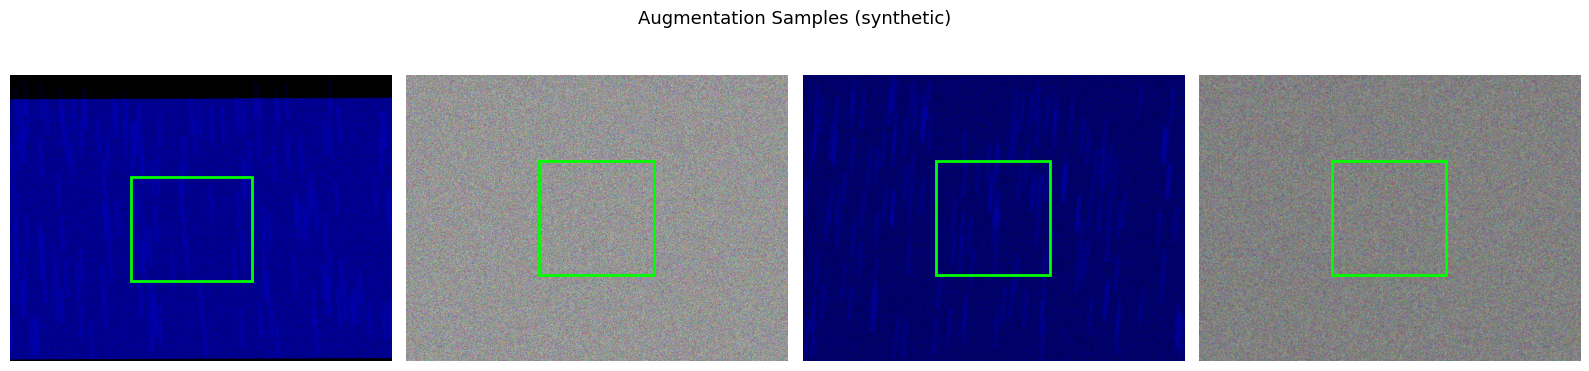

Augmentation preview done ✓


In [11]:
import albumentations as A

# Standard augmentation pipeline used during training
augment = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.RandomBrightnessContrast(p=0.4),
    A.GaussianBlur(blur_limit=(3, 7), p=0.2),
    A.HueSaturationValue(hue_shift_limit=15,
                          sat_shift_limit=25,
                          val_shift_limit=15, p=0.3),
    A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.1,
                       rotate_limit=10, p=0.4),
    A.RandomRain(p=0.1),
    A.RandomFog(p=0.1),
], bbox_params=A.BboxParams(format="yolo", label_fields=["class_labels"]))

# Demo on a synthetic image
demo_img = np.random.randint(100, 200, (480, 640, 3), dtype=np.uint8)
demo_box = [0.5, 0.5, 0.3, 0.4]   # cx, cy, w, h normalised

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax in axes:
    result = augment(image=demo_img, bboxes=[demo_box], class_labels=[2])
    aug_img = result["image"]
    boxes   = result["bboxes"]
    ax.imshow(cv2.cvtColor(aug_img, cv2.COLOR_BGR2RGB))
    for cx, cy, bw, bh in boxes:
        h, w = aug_img.shape[:2]
        x1 = int((cx - bw/2) * w); y1 = int((cy - bh/2) * h)
        x2 = int((cx + bw/2) * w); y2 = int((cy + bh/2) * h)
        rect = patches.Rectangle((x1, y1), x2-x1, y2-y1,
                                   linewidth=2, edgecolor="lime", facecolor="none")
        ax.add_patch(rect)
    ax.axis("off")
fig.suptitle("Augmentation Samples (synthetic)", fontsize=13)
plt.tight_layout()
plt.show()
print("Augmentation preview done ✓")

## 1.8  Class Distribution Check

In [12]:
def plot_class_distribution(labels_dir: str, class_names: list):
    counts = {c: 0 for c in class_names}
    label_files = list(Path(labels_dir).rglob("*.txt"))

    for lf in tqdm(label_files, desc="Counting"):
        for line in lf.read_text().splitlines():
            parts = line.strip().split()
            if parts:
                cls = int(parts[0])
                if cls < len(class_names):
                    counts[class_names[cls]] += 1

    names  = list(counts.keys())
    values = list(counts.values())

    plt.figure(figsize=(12, 5))
    bars = plt.bar(names, values, color="steelblue")
    plt.xticks(rotation=45, ha="right")
    plt.ylabel("Instance count")
    plt.title("Class Distribution in Dataset")
    for bar, v in zip(bars, values):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 str(v), ha="center", va="bottom", fontsize=8)
    plt.tight_layout()
    plt.show()
    return counts

# Uncomment when labels are ready:
# dist = plot_class_distribution(str(LABELS_DIR), CLASS_NAMES)
print("Distribution plotter defined ✓  (run after populating labels/)")

Distribution plotter defined ✓  (run after populating labels/)


## ✅ Notebook 1 Summary

- Directory structure created under `data/`
- COCO → YOLO conversion helper defined
- Train/val split helper defined
- `dataset.yaml` written
- Augmentation pipeline defined
- Class distribution plotter defined

**Next:** `02_model_training.ipynb`